In [11]:
"""This code compare VR methods to BSPPA with constant steps. One can see the effects of the variance of BSPPA.  At the moment the experiment is still
on going to make different tests.
"""

import numpy as np
import matplotlib.pyplot as plt

def kl_row_loss(z, b_i):
    z = max(z, 1e-15)
    if b_i <= 0:
        return z
    return b_i * np.log(b_i / z) - b_i + z


def objective(A, b, x):
    Ax = A @ x
    if np.any(Ax <= 0):
        return np.inf
    return np.mean([kl_row_loss(Ax[i], b[i]) for i in range(len(b))])


def grad_f_i(A, b, x, i):
    """
    ∇f_i(x) = (1 - b_i / (a_i^T x)) a_i
    """
    ai = A[i]
    z = ai @ x
    z = max(z, 1e-15)
    return (1.0 - b[i] / z) * ai

def full_gradient(A, b, x, eps=1e-15):
    """
    Full gradient for

        F(x) = (1/n) Σ_i [ b_i log(b_i/(Ax)_i) - b_i + (Ax)_i ]

    Parameters
    ----------
    A : ndarray (n, d)
    b : ndarray (n,)
    x : ndarray (d,)
    eps : float
        Numerical safeguard.

    Returns
    -------
    grad : ndarray (d,)
    """
    Ax = A @ x
    Ax = np.maximum(Ax, eps)

    coeff = 1.0 - b / Ax
    grad = A.T @ coeff

    return grad / A.shape[0]

def solve_subproblem(ai, b_i, xk, correction, gamma, tol=1e-12, max_iter=100):
    """
    Solve the implicit Bregman-VR step

        ∇h(x+) = ∇h(xk) - γ( ∇f_i(x+) + correction )

    where
        h(x) = -Σ log x_j
        ∇f_i(x) = a_i - (b_i / (a_i^T x)) a_i

    and correction is the constant vector
        correction = -∇f_i(x_tilde) + ∇F(x_tilde)

    This yields
        1/x+ = c - λ a_i
    with
        c = 1/xk + γ(a_i + correction)
        λ = γ b_i / (a_i^T x+)

    so λ solves
        λ Σ_j a_ij / (c_j - λ a_ij) = γ b_i.
    """
    ai = np.asarray(ai, dtype=float)
    xk = np.asarray(xk, dtype=float)
    correction = np.asarray(correction, dtype=float)

    c = 1.0 / xk + gamma * (ai + correction)

    if np.any(c <= 0):
        raise RuntimeError("Nonpositive c encountered. Try a smaller stepsize.")

    if b_i <= 0:
        return 1.0 / c

    support = ai > 0
    if not np.any(support):
        return 1.0 / c
        
    # solving 1-d root finding problem phi(lam) = 0
    def phi(lam):
        denom = c - lam * ai
        return lam * np.sum(ai[support] / denom[support]) - gamma * b_i

    lam_hi = np.min(c[support] / ai[support])
    lo = 0.0
    hi = lam_hi * (1.0 - 1e-12)

    fhi = phi(hi)
    shrink = 0
    while (not np.isfinite(fhi) or fhi <= 0) and shrink < 60:
        hi *= 0.5
        fhi = phi(hi)
        shrink += 1

    if not np.isfinite(fhi) or fhi <= 0:
        raise RuntimeError("Could not bracket the scalar root. Try a smaller stepsize.")

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fm = phi(mid)
        if abs(fm) <= tol:
            lam = mid
            break
        if fm > 0:
            hi = mid
        else:
            lo = mid
    else:
        lam = 0.5 * (lo + hi)

    denom = c - lam * ai
    if np.any(denom <= 0):
        raise RuntimeError("Implicit step failed: nonpositive denominator.")

    return 1.0 / denom


def bregman_sapa_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=100,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit Bregman-SAGA for

        F(x) = (1/n) sum_i [ b_i log(b_i / (Ax)_i) - b_i + (Ax)_i ]

    on R_{++}^d, with h(x) = -sum_j log x_j.

    Update:
        x^{k+1} = argmin_x gamma*( f_i(x) - <alpha_i,x> + <mean_alpha,x> ) + D_h(x,x^k)

    where alpha_i stores the last gradient of f_i.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    # Initialize SAPA memory
    grad_table = np.zeros((n, d), dtype=float)
    mean_grad = np.zeros(d, dtype=float)

    for i in range(n):
        gi = grad_f_i(A, b, x, i)
        grad_table[i] = gi
        mean_grad += gi
    mean_grad /= n

    history = {"obj": [], "x": []} if store_history else None

    total_iters = 3 * max_epochs * n -n

    for k in range(total_iters):
        i = rng.integers(n)
        ai = A[i]
        alpha_i = grad_table[i].copy()

        # Implicit solve
        x_new = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            correction= - alpha_i + mean_grad,
            gamma=stepsize,
        )

        # Refresh the stored gradient for row i at the new point
        gi_new = grad_f_i(A, b, x_new, i)

        # SAPA memory update
        mean_grad += (gi_new - grad_table[i]) / n
        grad_table[i] = gi_new

        x = x_new

        if store_history and ((k + 1) % n == 0):
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            if verbose:
                epoch = (k + 1) // n
                print(f"epoch={epoch:4d}, obj={fval:.8e}")

    return x, history


def bregman_svrp_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=50,
    inner_steps=None,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit Bregman-SVRG for

        F(x) = (1/n) Σ_i [ b_i log(b_i / (Ax)_i) - b_i + (Ax)_i ]

    on R_{++}^d with h(x) = -Σ log x_j.

    Outer loop:
        x_tilde = reference point
        g_tilde = ∇F(x_tilde)

    Inner loop:
        choose i_k uniformly
        v_k(x) = ∇f_{i_k}(x) - ∇f_{i_k}(x_tilde) + g_tilde

        x^{k+1} solves
            ∇h(x^{k+1}) = ∇h(x^k) - γ v_k(x^{k+1})

    Because only ∇f_{i_k}(x^{k+1}) is implicit, the step reduces
    to a 1D bisection.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    if inner_steps is None:
        inner_steps = n

    history = {"obj": [], "x": []} if store_history else None

    for epoch in range(max_epochs):
        x_tilde = x.copy()
        g_tilde = full_gradient(A, b, x_tilde)

        x_inner = x_tilde.copy()

        for _ in range(inner_steps):
            i = rng.integers(n)
            ai = A[i]

            grad_i_tilde = grad_f_i(A, b, x_tilde, i)
            correction = -grad_i_tilde + g_tilde

            x_inner = solve_subproblem(
                ai=ai,
                b_i=b[i],
                xk=x_inner,
                correction=correction,
                gamma=stepsize,
            )

        x = x_inner

        if store_history:
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())

        if verbose:
            fval = objective(A, b, x)
            print(f"epoch={epoch + 1:4d}, obj={fval:.8e}")

    return x, history

def bregman_sppa_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=100,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit stochastic Bregman method for

        F(x) = (1/n) sum_i [ b_i log(b_i / (Ax)_i) - b_i + (Ax)_i ]

    with h(x) = -sum_j log x_j.

    Iteration:
        sample i_k uniformly
        x^{k+1} = argmin_{x>0} gamma * f_{i_k}(x) + D_h(x, x^k)

    This is implicit, but not variance-reduced.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    history = {"obj": [], "x": []} if store_history else None

    total_iters = 3 * max_epochs * n

    for k in range(total_iters):
        i = rng.integers(n)
        ai = A[i]

        x = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            gamma=stepsize,
            correction=0.0,
        )

        if store_history and ((k + 1) % n == 0):
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            if verbose:
                epoch = (k + 1) // n
                print(f"epoch={epoch:4d}, obj={fval:.8e}")

    return x, history

import numpy as np


def bregman_lsvrp_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=1000,
    snapshot_prob=None,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit loopless Bregman-SVRP for

        F(x) = (1/n) Σ_i [ b_i log(b_i / (Ax)_i) - b_i + (Ax)_i ]

    on R_{++}^d with mirror kernel

        h(x) = -Σ_j log x_j.

    At iteration k:
        choose i_k uniformly
        v_k(x) = ∇f_{i_k}(x) - ∇f_{i_k}(x_snap) + ∇F(x_snap)

        x^{k+1} solves
            ∇h(x^{k+1}) = ∇h(x^k) - γ v_k(x^{k+1})

    After the step, the snapshot is refreshed with Bernoulli probability
    snapshot_prob.

    Parameters
    ----------
    A : ndarray, shape (n, d)
        Nonnegative matrix.
    b : ndarray, shape (n,)
        Nonnegative data vector.
    x0 : ndarray, shape (d,)
        Initial strictly positive iterate.
    stepsize : float
        Constant stepsize.
    max_iter : int
        Number of stochastic iterations.
    snapshot_prob : float or None
        Bernoulli probability for refreshing the snapshot.
        If None, defaults to 1 / n.
    seed : int
        Random seed.
    store_history : bool
        If True, store objective and iterate history.
    verbose : bool
        If True, print occasional progress.

    Returns
    -------
    x : ndarray, shape (d,)
        Final iterate.
    history : dict or None
        If store_history is True, contains:
            - "obj": list of objective values
            - "x": list of iterates
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    if snapshot_prob is None:
        snapshot_prob = 1.0 / n
    if not (0.0 < snapshot_prob <= 1.0):
        raise ValueError("snapshot_prob must belong to (0, 1].")

    history = {"obj": [], "x": []} if store_history else None

    # Initial snapshot
    x_snap = x.copy()
    g_snap = full_gradient(A, b, x_snap)

    if store_history:
        history["obj"].append(objective(A, b, x))
        history["x"].append(x.copy())

    total_iters = max_epochs * n

    for k in range(total_iters):
        i = rng.integers(n)
        ai = A[i]

        grad_i_snap = grad_f_i(A, b, x_snap, i)
        correction = -grad_i_snap + g_snap

        x = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            correction=correction,
            gamma=stepsize,
        )

        # Bernoulli refresh of the snapshot
        if rng.random() < snapshot_prob:
            x_snap = x.copy()
            g_snap = full_gradient(A, b, x_snap)

        if store_history and ((k + 1) % n == 0):
            history["obj"].append(objective(A, b, x))
            history["x"].append(x.copy())

        if verbose and ((k + 1) % max(1, n) == 0):
            print(f"iter={k + 1:6d}, obj={objective(A, b, x):.8e}")

    return x, history


Running j = 1.0, step_size = 1.1111e-01
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


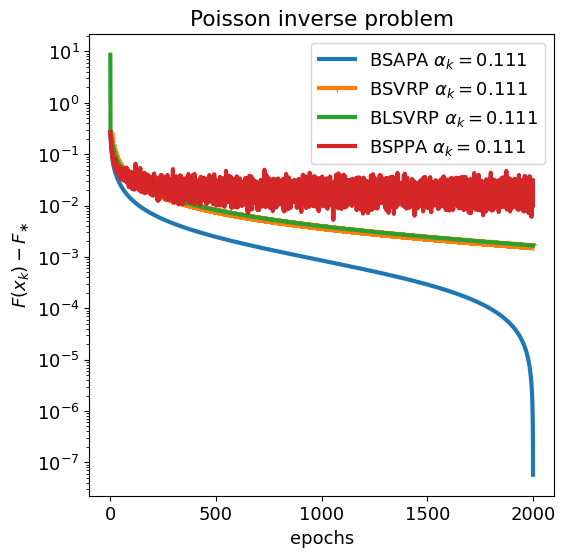


Running j = 2.0, step_size = 2.2222e-01
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


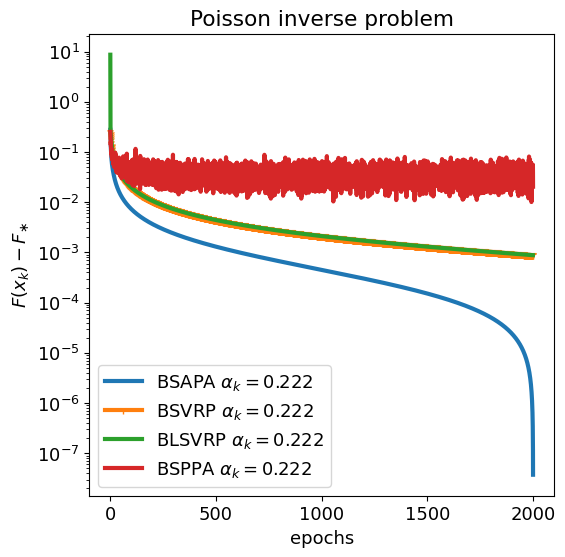


Running j = 3.0, step_size = 3.3333e-01
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


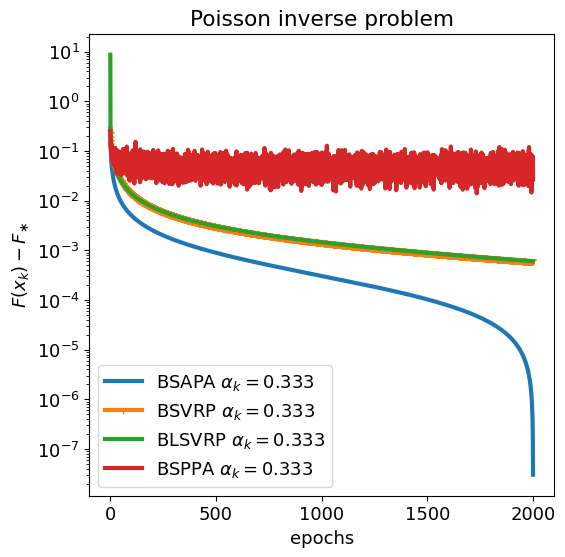

In [12]:
def get_stepsize_label(j):
    tmp = 1.0 / j
    if np.isclose(j, 5):
        return r"$\alpha_k = 1/L$"
    elif np.isclose(j, 10) or np.isclose(j, 25):
        return r"$\alpha_k = {}/L$".format(int(j / 5 + 0.3))
    else:
        return r"$\alpha_k = 1/{}L$".format(int(5 * tmp + 0.3))

import math

def truncate(x, decimals=0):
    factor = 10.0 ** decimals
    return math.trunc(x * factor) / factor

def stack_histories_with_nan(hist_list):
    max_len = max(len(h) for h in hist_list)
    out = np.full((len(hist_list), max_len), np.nan, dtype=float)
    for i, h in enumerate(hist_list):
        out[i, :len(h)] = h
    return out

def plot_mean_std(ax, x, mean, std, f_star, label, use_shading=True, marker=None):
    y = np.maximum(mean - f_star, 1e-16)
    ax.plot(x, y, label=label, marker=marker)

    if use_shading:
        y_low = np.maximum(mean - std - f_star, 1e-16)
        y_high = np.maximum(mean + std - f_star, 1e-16)
        ax.fill_between(x, y_low, y_high, alpha=0.2)

rng = np.random.default_rng(42)

# Toggle shading here
use_shading = False

n, d = 100, 100

A = np.random.rand(n,d)
x_true = np.random.rand(d)

Ax_true = A @ x_true

b = rng.poisson(np.maximum(Ax_true, 1e-3)).astype(float)
b = np.maximum(b, 1e-8)

x0 = np.ones(d)

L = b.max()
maxepochs = 2000
n_runs = 10
base_seed = 42

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["lines.linewidth"] = 3

for j in [1., 2., 3.]:
    tmp = 1.0 / (20*j)
    step_size = 1.0 / (5 * tmp * L)

    print(f"\nRunning j = {j}, step_size = {step_size:.4e}")

    all_sapa = []
    all_svrp = []
    all_lsvrp = []
    all_sppa = []

    for run in range(n_runs):
        seed = base_seed + 10*run

        _, hist_sapa = bregman_sapa_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            seed=seed,
            verbose=False,
        )

        _, hist_svrp = bregman_svrp_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            inner_steps=n,
            seed=seed,
            verbose=False,
        )

        _, hist_lsvrp = bregman_lsvrp_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            seed=seed,
            verbose=False,
        )


        _, hist_sppa = bregman_sppa_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            seed=seed,
            verbose=False,
        )

        all_sapa.append(np.asarray(hist_sapa["obj"], dtype=float))
        all_svrp.append(np.asarray(hist_svrp["obj"], dtype=float))
        all_lsvrp.append(np.asarray(hist_lsvrp["obj"], dtype=float))
        all_sppa.append(np.asarray(hist_sppa["obj"], dtype=float))

        print(f"  run {run + 1}/{n_runs} done")

    all_sapa = stack_histories_with_nan(all_sapa)
    all_svrp = stack_histories_with_nan(all_svrp)
    all_lsvrp = stack_histories_with_nan(all_lsvrp)
    all_sppa = stack_histories_with_nan(all_sppa)

    f_star = min(
        np.nanmin(all_sapa),
        np.nanmin(all_svrp),
        np.nanmin(all_lsvrp),
        np.nanmin(all_sppa),
    )

    mean_sapa = np.nanmean(all_sapa, axis=0)
    std_sapa = np.nanstd(all_sapa, axis=0)

    mean_svrp = np.nanmean(all_svrp, axis=0)
    std_svrp = np.nanstd(all_svrp, axis=0)

    mean_lsvrp = np.nanmean(all_lsvrp, axis=0)
    std_lsvrp = np.nanstd(all_lsvrp, axis=0)

    mean_sppa = np.nanmean(all_sppa, axis=0)
    std_sppa = np.nanstd(all_sppa, axis=0)

    fig, ax = plt.subplots()

    label_suffix = r"$\alpha_k = {}$".format(truncate(step_size, 3))

    plot_mean_std(
        ax,
        (maxepochs/len(mean_sapa))*np.arange(len(mean_sapa)),
        mean_sapa,
        std_sapa,
        f_star,
        f"BSAPA {label_suffix}",
        use_shading,
    )

    plot_mean_std(
        ax,
        (maxepochs/len(mean_svrp))*np.arange(len(mean_svrp)),
        mean_svrp,
        std_svrp,
        f_star,
        f"BSVRP {label_suffix}",
        use_shading,
        marker="1"
    )

    plot_mean_std(
        ax,
        (maxepochs/len(mean_lsvrp))*np.arange(len(mean_lsvrp)),
        mean_lsvrp,
        std_lsvrp,
        f_star,
        f"BLSVRP {label_suffix}",
        use_shading,
    )

    plot_mean_std(
        ax,
        (maxepochs/len(mean_sppa))*np.arange(len(mean_sppa)),
        mean_sppa,
        std_sppa,
        f_star,
        f"BSPPA {label_suffix}",
        use_shading,
    )

    ax.set_yscale("log")
    ax.set_ylabel(r"$F(x_k) - F_{\ast}$")
    ax.set_xlabel("epochs")
    ax.set_title(f"Poisson inverse problem")
    ax.legend()

    suffix = "_shaded" if use_shading else ""
    # fig.savefig("Rebuttal/Plots/poisson_{}_avg_{}_all_interpolation.png".format(j, suffix), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()
